In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)
import importlib
import models.pretrained_resnet as resnet
importlib.reload(resnet)
import utilities.util_metrics as metrics
importlib.reload(metrics)
import utilities.util_dataloader as dataloader
importlib.reload(dataloader)

<module 'utilities.util_dataloader' from 'c:\\Users\\frank\\OneDrive\\Documents\\vsCodeProjects\\cytology\\utilities\\util_dataloader.py'>

In [ ]:
#data
from importlib import util


batch_size = 16
img_size = (224, 224)
directory = 'C:\\Users\\frank\\OneDrive\\Documents\\vsCodeProjects\\cytology\\data'
seed = 100

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory,
    validation_split=0.4,  
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)


temp_ds = tf.keras.utils.image_dataset_from_directory(
    directory,
    validation_split=0.4,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
temp_ds = temp_ds.cache().prefetch(buffer_size=AUTOTUNE)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])


X_train, y_train = util.dataloaderNumpy(train_ds)
X_val, y_val = util.dataloaderNumpy(temp_ds)

print(X_train.shape, y_train.shape)

Found 600 files belonging to 3 classes.
Using 360 files for training.
Found 600 files belonging to 3 classes.
Using 240 files for validation.
(360, 224, 224, 3) (360,)


In [ ]:

#Build
X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)
model = resnet.build_resnet(input_shape=X_train.shape[1:], num_classes=len(np.unique(y_train)))

In [25]:
#Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#optimize
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_control_cnn.h5",
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.3549 - loss: 1.7333

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 422ms/step - accuracy: 0.3861 - loss: 1.5420 - val_accuracy: 0.6167 - val_loss: 0.8784
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.4568 - loss: 1.1688

23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - accuracy: 0.5306 - loss: 1.0493 - val_accuracy: 0.7167 - val_loss: 0.7111
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.5749 - loss: 0.9102

23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 384ms/step - accuracy: 0.6139 - loss: 0.8440 - val_accuracy: 0.7500 - val_loss: 0.6472
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 383ms/step - accuracy: 0.6389 - loss: 0.7483 - val_accuracy: 0.7500 - val_loss: 0.6166
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.7163 - loss: 0.7049

23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 492ms/step - accuracy: 0.7111 - loss: 0.6951 - val_accuracy: 0.7750 - val_loss: 0.5889
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 494ms/step - accuracy: 0.7222 - loss: 0.6829 - val_accuracy: 0.7583 - val_loss: 0.5769
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 468ms/step - accuracy: 0.7611 - loss: 0.5788 - val_accuracy: 0.7750 - val_loss: 0.5478
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 493ms/step - accuracy: 0.7583 - loss: 0.5623 - val_accuracy: 0.7417 - val_loss: 0.5353
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.7413 - loss: 0.6019

...

23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 780ms/step - accuracy: 0.8528 - loss: 0.4201 - val_accuracy: 0.8583 - val_loss: 0.4355
Epoch 17/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8388 - loss: 0.4400

23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 825ms/step - accuracy: 0.8667 - loss: 0.4184 - val_accuracy: 0.8667 - val_loss: 0.4201
Epoch 18/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 809ms/step - accuracy: 0.8750 - loss: 0.3755 - val_accuracy: 0.8417 - val_loss: 0.4120
Epoch 19/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.8401 - loss: 0.4181

23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 825ms/step - accuracy: 0.8500 - loss: 0.4156 - val_accuracy: 0.8917 - val_loss: 0.4106
Epoch 20/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 784ms/step - accuracy: 0.8972 - loss: 0.3670 - val_accuracy: 0.8833 - val_loss: 0.3831
Epoch 21/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 769ms/step - accuracy: 0.8944 - loss: 0.3456 - val_accuracy: 0.8667 - val_loss: 0.3836
Epoch 22/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 779ms/step - accuracy: 0.8917 - loss: 0.3435 - val_accuracy: 0.8750 - val_loss: 0.3783
Epoch 23/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 773ms/step - accuracy: 0.8722 - loss: 0.3549 - val_accuracy: 0.8667 - val_loss: 0.3762
Epoch 24/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 721ms/step - accuracy: 0.8778 - loss: 0.3316 - val_accuracy: 0.8917 - val_loss: 0.3734
Epoch 25/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 676ms/step - accuracy: 0.8944 - loss: 0.3444 - val_accuracy: 0.8750 - val_loss: 0.3597
Epoch 26/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 649ms/step - accuracy: 0.8889 - loss: 0.3234 - val_accuracy

23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 618ms/step - accuracy: 0.9222 - loss: 0.2703 - val_accuracy: 0.9000 - val_loss: 0.3429
Epoch 29/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9020 - loss: 0.2732

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 592ms/step - accuracy: 0.9000 - loss: 0.2843 - val_accuracy: 0.9083 - val_loss: 0.3413
Epoch 30/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 570ms/step - accuracy: 0.9028 - loss: 0.2915 - val_accuracy: 0.8667 - val_loss: 0.3498


In [ ]:
#prediction
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = y_val

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step  


Accuracy: 0.9083333333333333
F1 Score: 0.9082962962962963
AUC: 0.969017073934837


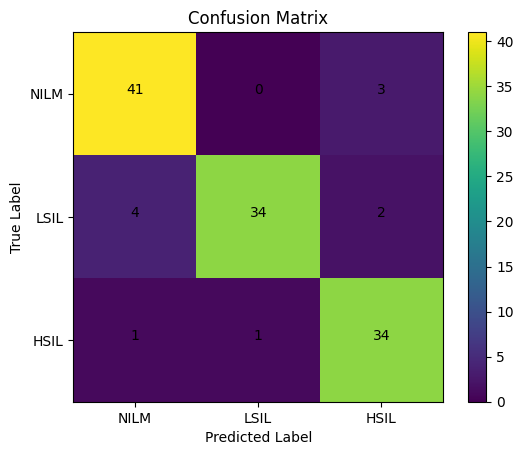

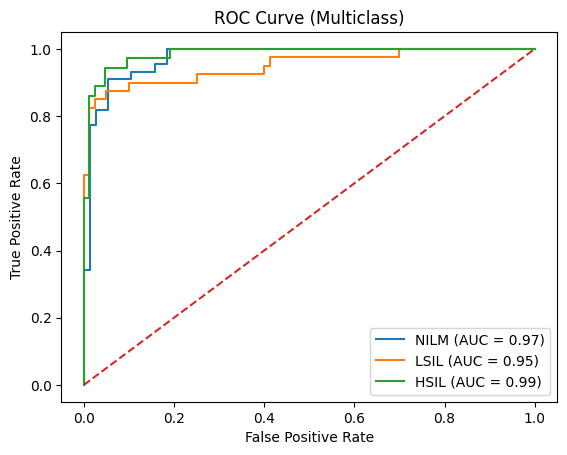

{0: 0.9739832535885167, 1: 0.9490625, 2: 0.9851190476190477}

In [ ]:
#results 
acc = metrics.compute_accuracy(y_true, y_pred)
f1 = metrics.compute_f1(y_true, y_pred)
auc_score = metrics.compute_auc(y_true, y_pred_probs, num_classes=3)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("AUC:", auc_score)

class_names = ["NILM", "LSIL", "HSIL"]

metrics.plot_confusion_matrix(y_true, y_pred, class_names)
metrics.plot_roc_multiclass(y_true, y_pred_probs, 3, class_names)